# Jaynes Cumming Model
The Jaynes-Cumming model describes a two level atom interacting with a single quantized mode of the electromagnetic field within the rotating-wave approximation.

The total hamiltonian is
$$H_{JC} = \frac{\hbar\omega_a}{2}\hat \sigma_z + \hbar\omega_c a^\dagger a + i\hbar g( a-a^\dagger)\sigma_x$$
where $\omega_a$ is the atomic transition frecuency, $\omega_c$ in the cavity mode frecuency and $g$ is the atom-field coupling strength. Field zero point energy was omitted.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.special import gammaln

## Quantum Rabi Oscilation 
$$P_e(t) = \frac{1-\cos(\Omega_Nt)}{2(1+\Delta^2/(4Ng^2))}, \quad \Omega_N=\sqrt{\Delta^2+4Ng^2},$$
$$P_e(t) = \frac{1-\cos(2\sqrt{N+\delta^2}\tau)}{2(1+\delta^2/N)},\quad \delta=\Delta/2g,\quad \tau = gt $$


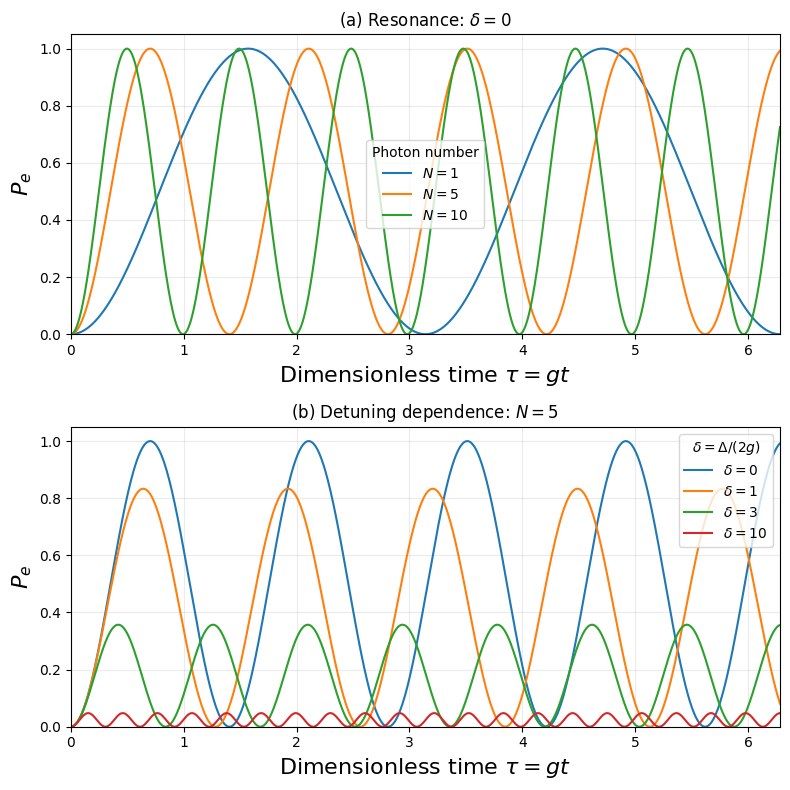

In [9]:
# Dimensionless time tau = g t
tau = np.linspace(0.0, 2.0 * np.pi, 1500)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 8),
    sharey=True,
)

# ------------------------------------------------------------------
# Panel (a): photon-number dependence at resonance
# ------------------------------------------------------------------

N_values = [1,5, 10]
delta = 0.0

for N in N_values:
    omega_N = np.sqrt(N + delta**2)

    P_e = (
        np.sin(omega_N * tau)**2
        / (1.0 + delta**2 / N)
    )

    axes[0].plot(
        tau,
        P_e,
        label=rf"$N={N}$",
    )

axes[0].set_xlabel(r"Dimensionless time $\tau=gt$",fontsize=16)
axes[0].set_ylabel(r"$P_e$",fontsize=16)
axes[0].set_title(r"(a) Resonance: $\delta=0$")
axes[0].set_xlim(tau[0], tau[-1])
axes[0].set_ylim(0.0, 1.05)
axes[0].legend(title="Photon number")
axes[0].grid(alpha=0.25)

# ------------------------------------------------------------------
# Panel (b): detuning dependence at fixed photon number
# ------------------------------------------------------------------

N = 5
delta_values = [0.0, 1.0, 3.0, 10.0]

for delta in delta_values:
    omega_N = np.sqrt(N + delta**2)

    P_e = (
        np.sin(omega_N * tau)**2
        / (1.0 + delta**2 / N)
    )

    axes[1].plot(
        tau,
        P_e,
        label=rf"$\delta={delta:g}$",
    )

axes[1].set_xlabel(r"Dimensionless time $\tau=gt$",fontsize=16)
axes[1].set_ylabel(r"$P_e$",fontsize=16)
axes[1].set_title(rf"(b) Detuning dependence: $N={N}$")
axes[1].set_xlim(tau[0], tau[-1])
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(title=r"$\delta=\Delta/(2g)$")
axes[1].grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    "Figures/quantum-rabi-oscillation.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


## Collapses and revival under initial coherent light
$$P_n = e^{-\bar n}\frac{\bar{n}^n}{n!}$$



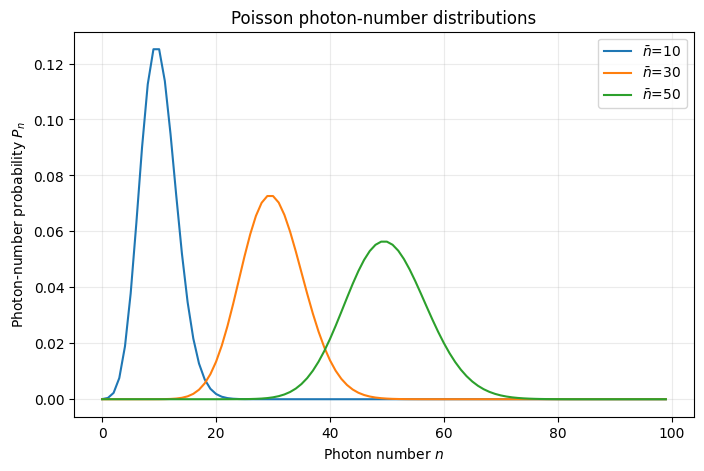

In [11]:
n_bar_values = [10,30,50]
fig, ax = plt.subplots(figsize=(8, 5))

for n_bar in n_bar_values:
    n_values = np.array(range(100))
    P_n = np.exp(-n_bar+n_values*np.log(n_bar)-gammaln(n_values+1))
    ax.plot(n_values, P_n,label=rf'$\bar n$={n_bar}')

ax.set_xlabel(r"Photon number $n$")
ax.set_ylabel(r"Photon-number probability $P_n$")
ax.set_title("Poisson photon-number distributions")

ax.legend()
ax.grid(alpha=0.25)
plt.savefig("Figures/poisson-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()


$$P_e = \frac{1}{2}-\frac{1}{2}\sum_{n=0}^\infty \frac{e^{-\bar n}\bar n^n}{n!}\cos(2\sqrt{n}gt)$$

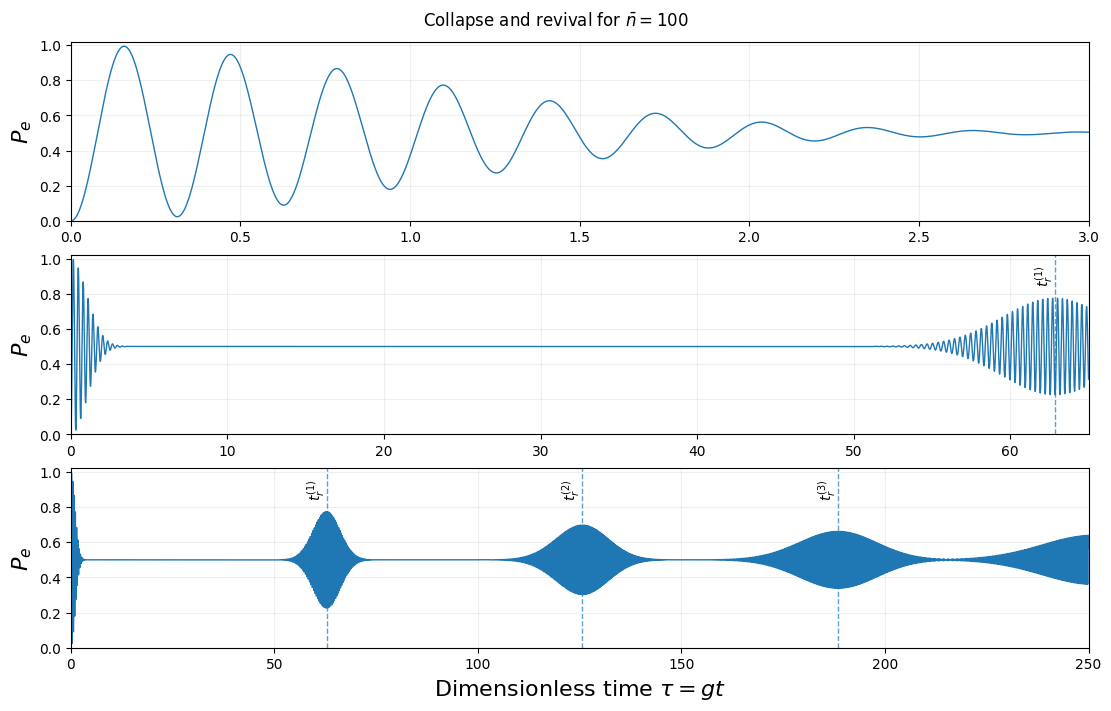

In [13]:
n_bar = 100.0
time_max_values = [3.0, 65.0, 250.0]
tolerance = 1e-12

# Truncation of the coherent-state photon distribution
n_max = int(
    poisson.ppf(
        1.0 - tolerance,
        mu=n_bar,
    )
)

n_values = np.arange(0, n_max + 1)

# Poisson weights
log_weights = (
    -n_bar
    + n_values * np.log(n_bar)
    - gammaln(n_values + 1)
)

weights = np.exp(log_weights)

# Normalize after numerical truncation
weights /= np.sum(weights)

fig, axes = plt.subplots(
    nrows=len(time_max_values),
    ncols=1,
    figsize=(11, 7),
    constrained_layout=True,
)

for ax, tau_max in zip(axes, time_max_values):
    # Increase resolution for longer time intervals
    number_of_points = max(
        3000,
        int(120 * tau_max),
    )

    tau = np.linspace(
        0.0,
        tau_max,
        number_of_points,
    )

    # Matrix with shape (number of photon states, number of times)
    phases = (
        2.0
        * np.sqrt(n_values[:, np.newaxis])
        * tau[np.newaxis, :]
    )

    atomic_inversion = np.sum(
        weights[:, np.newaxis] * np.cos(phases),
        axis=0,
    )

    P_e = 0.5 * (1.0 - atomic_inversion)

    ax.plot(
        tau,
        P_e,
        linewidth=1.0,
    )

    ax.set_xlim(0.0, tau_max)
    ax.set_ylim(0.0, 1.02)
    ax.set_ylabel(r"$P_e$",fontsize=16)
    ax.grid(alpha=0.2)

    # Add predicted revival times
    first_revival = 2.0 * np.pi * np.sqrt(n_bar)
    maximum_m = int(np.floor(tau_max / first_revival))

    for m in range(1, maximum_m + 1):
        revival_time = m * first_revival

        ax.axvline(
            revival_time,
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

        ax.text(
            revival_time,
            0.96,
            rf"$t_r^{{({m})}}$",
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
        )

axes[-1].set_xlabel(r"Dimensionless time $\tau=gt$",fontsize=16)

fig.suptitle(
    rf"Collapse and revival for $\bar{{n}}={n_bar:g}$",
)

fig.savefig(
    "Figures/collapse-and-revivals.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)
